# 04 - Random Forest tuning final

Tuning final del Random Forest. Aqui probamos varias combinaciones de hiperparametros con validacion cruzada y despues evaluamos el modelo en train, test y OOS.

In [16]:
# Cargamos librerias, src y carpetas de salida.
import os
os.environ.setdefault('MPLCONFIGDIR', '../outputs/matplotlib')

import sys
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, roc_auc_score

sys.path.append('../src')
from preprocessing import get_numeric_preprocessor
from evaluation import (
    evaluate_binary_model,
    threshold_by_ks,
    psi_table,
    population_stability_index,
    psi_interpretation,
)

os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

## 1. Cargar splits

In [17]:
# Leemos los splits comunes para entrenar y evaluar.
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
X_oos = pd.read_csv('../data/X_oos.csv')

y_train = pd.read_csv('../data/y_train.csv')['target']
y_test = pd.read_csv('../data/y_test.csv')['target']
y_oos = pd.read_csv('../data/y_oos.csv')['target']

print('Train:', X_train.shape, 'bad rate:', round(y_train.mean(), 4))
print('Test :', X_test.shape, 'bad rate:', round(y_test.mean(), 4))
print('OOS  :', X_oos.shape, 'bad rate:', round(y_oos.mean(), 4))

Train: (6872, 120) bad rate: 0.0806
Test : (1964, 120) bad rate: 0.081
OOS  : (982, 120) bad rate: 0.0804


In [18]:
# Filtramos a variables candidatas: 0.10 <= IV < 0.50.
# Variables con IV >= 0.50 se excluyen por criterio prudencial de posible Data Leakage.
# El bivariado (notebook 02) debe haberse ejecutado antes para que exista este CSV.
bivariado = pd.read_csv('../outputs/bivariado_final.csv')
variables_candidatas = bivariado[
    (bivariado['iv'] >= 0.10) & (bivariado['iv'] < 0.50)
]['variable'].tolist()
variables_candidatas = [v for v in variables_candidatas if v in X_train.columns]

X_train = X_train[variables_candidatas]
X_test  = X_test[variables_candidatas]
X_oos   = X_oos[variables_candidatas]

print(f'Variables usadas en modelado (0.10 <= IV < 0.50): {len(variables_candidatas)}')

Variables usadas en modelado (0.10 <= IV < 0.50): 33


## 2. Buscar mejores hiperparametros

In [19]:
# Configuramos la busqueda de hiperparametros del Random Forest.
# class_weight queda fijo en 'balanced', como pide el plan del dia 2.
rf_pipe = Pipeline(steps=[
    ('preprocess', get_numeric_preprocessor()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [5, 7, 9, 12, None],
    'model__max_features': ['sqrt', 0.3, 0.5],
    'model__min_samples_leaf': [10, 20, 50, 100],
    'model__min_samples_split': [20, 50, 100]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [20]:
# Guardamos resultados del tuning y los mejores parametros.
tuning_results = pd.DataFrame(search.cv_results_)
tuning_results.to_csv('../outputs/rf_tuning_results.csv', index=False)

best_params = pd.DataFrame([search.best_params_])
best_params['model__class_weight'] = 'balanced'
best_params['best_cv_auc'] = search.best_score_
best_params.to_csv('../outputs/rf_best_params.csv', index=False)

best_params

,model__n_estimators,model__min_samples_split,model__min_samples_leaf,model__max_features,model__max_depth,model__class_weight,best_cv_auc
0,500,20,10,0.3,None,balanced,0.791306


## 3. Evaluar modelo final

In [21]:
# Evaluamos el mejor modelo en train, test y oos.
p_train = best_model.predict_proba(X_train)[:, 1]
p_test = best_model.predict_proba(X_test)[:, 1]
p_oos = best_model.predict_proba(X_oos)[:, 1]

threshold = threshold_by_ks(y_train, p_train)

metricas_finales = pd.DataFrame([
    {'split': 'train', **evaluate_binary_model(y_train, p_train, threshold)},
    {'split': 'test', **evaluate_binary_model(y_test, p_test, threshold)},
    {'split': 'oos', **evaluate_binary_model(y_oos, p_oos, threshold)}
])

train_auc = metricas_finales.loc[metricas_finales['split'] == 'train', 'auc'].iloc[0]
metricas_finales['gap_auc_vs_train'] = train_auc - metricas_finales['auc']

psi_test = population_stability_index(p_train, p_test, n_bins=10)
psi_oos = population_stability_index(p_train, p_oos, n_bins=10)

metricas_finales['psi_vs_train'] = metricas_finales['split'].map({
    'train': 0.0,
    'test': psi_test,
    'oos': psi_oos
})
metricas_finales['psi_interpretacion'] = metricas_finales['psi_vs_train'].apply(psi_interpretation)
metricas_finales.loc[metricas_finales['split'] == 'train', 'psi_interpretacion'] = 'Referencia'

metricas_finales.to_csv('../outputs/rf_final_metrics.csv', index=False)
metricas_finales

,split,auc,gini,ks,pr_auc,precision,recall,threshold,tn,fp,fn,tp,gap_auc_vs_train,psi_vs_train,psi_interpretacion
0,train,0.989230,0.978460,0.938709,0.860622,0.648456,0.985560,0.456445,6022,296,8,546,0.000000,0.000000,Referencia
1,test,0.753797,0.507594,0.389292,0.244152,0.265193,0.301887,0.456445,1672,133,111,48,0.235433,0.026792,Estable
2,oos,0.773414,0.546827,0.461598,0.248364,0.252632,0.303797,0.456445,832,71,55,24,0.215816,0.052133,Estable


## 4. PSI del score

In [22]:
# Guardamos el detalle del PSI por bin.
psi_test_table = psi_table(p_train, p_test, n_bins=10)
psi_oos_table = psi_table(p_train, p_oos, n_bins=10)

psi_test_table.to_csv('../outputs/rf_psi_test.csv', index=False)
psi_oos_table.to_csv('../outputs/rf_psi_oos.csv', index=False)

psi_resumen = pd.DataFrame([
    {'comparacion': 'train_vs_test', 'psi': psi_test, 'interpretacion': psi_interpretation(psi_test)},
    {'comparacion': 'train_vs_oos', 'psi': psi_oos, 'interpretacion': psi_interpretation(psi_oos)}
])
psi_resumen.to_csv('../outputs/rf_psi.csv', index=False)
psi_resumen

,comparacion,psi,interpretacion
0,train_vs_test,0.026792,Estable
1,train_vs_oos,0.052133,Estable


## 5. Importancia de variables

In [23]:
# Calculamos importancia de variables del modelo final.
modelo_rf = best_model.named_steps['model']
imputer = best_model.named_steps['preprocess'].named_steps['imputer']

nombres = list(X_train.columns)

if imputer.add_indicator and hasattr(imputer, 'indicator_'):
    for posicion in imputer.indicator_.features_:
        nombres.append(X_train.columns[posicion] + '_missing')

importancias = pd.DataFrame({
    'feature': nombres,
    'importance': modelo_rf.feature_importances_
}).sort_values('importance', ascending=False)

importancias.to_csv('../outputs/rf_final_feature_importance.csv', index=False)
importancias.head(20)

,feature,importance
0,x120,0.069807
1,x85,0.064709
5,x99,0.062905
25,x11,0.049050
2,x87,0.046797
29,x16,0.043087
4,x81,0.040773
28,x15,0.039822
22,x20,0.037350
6,x112,0.035118


## 6. Curva ROC final

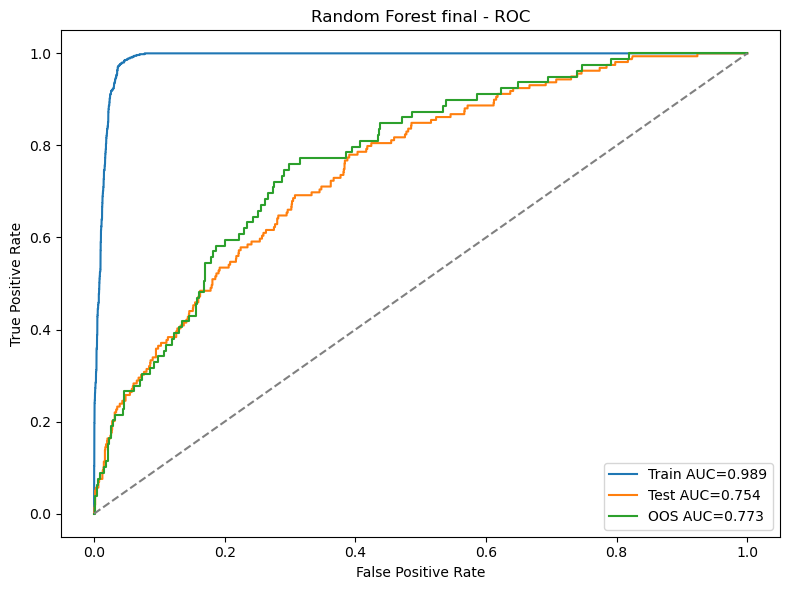

In [24]:
# Graficamos las curvas ROC del modelo final.
plt.figure(figsize=(8, 6))

for nombre, y_real, score in [
    ('Train', y_train, p_train),
    ('Test', y_test, p_test),
    ('OOS', y_oos, p_oos)
]:
    fpr, tpr, _ = roc_curve(y_real, score)
    auc = roc_auc_score(y_real, score)
    plt.plot(fpr, tpr, label=f'{nombre} AUC={auc:.3f}')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest final - ROC')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/rf_final_roc_train_test_oot.png', dpi=200)
plt.show()

## 7. KS final

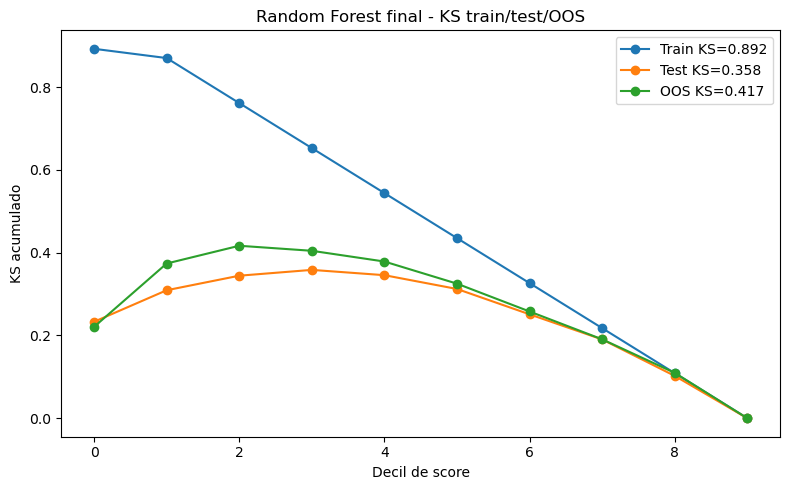

In [25]:
# Graficamos el KS por decil para train, test y oos.
def tabla_ks(y_real, score, n_bins=10):
    datos = pd.DataFrame({'y': y_real, 'score': score})
    datos['decil'] = pd.qcut(datos['score'], q=n_bins, duplicates='drop')

    tabla = datos.groupby('decil', observed=False).agg(n=('y', 'count'), malos=('y', 'sum'))
    tabla = tabla.sort_index(ascending=False)
    tabla['buenos'] = tabla['n'] - tabla['malos']
    tabla['malos_acum'] = tabla['malos'].cumsum() / tabla['malos'].sum()
    tabla['buenos_acum'] = tabla['buenos'].cumsum() / tabla['buenos'].sum()
    tabla['ks'] = abs(tabla['malos_acum'] - tabla['buenos_acum'])
    return tabla.reset_index()

ks_tablas = []
plt.figure(figsize=(8, 5))

for nombre, y_real, score in [
    ('Train', y_train, p_train),
    ('Test', y_test, p_test),
    ('OOS', y_oos, p_oos)
]:
    tabla = tabla_ks(y_real, score)
    tabla['split'] = nombre.lower()
    ks_tablas.append(tabla)
    plt.plot(range(len(tabla)), tabla['ks'], marker='o', label=f'{nombre} KS={tabla["ks"].max():.3f}')

ks_final = pd.concat(ks_tablas, ignore_index=True)
ks_final.to_csv('../outputs/rf_final_ks_deciles.csv', index=False)

plt.xlabel('Decil de score')
plt.ylabel('KS acumulado')
plt.title('Random Forest final - KS train/test/OOS')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/rf_final_ks_train_test_oot.png', dpi=200)
plt.show()

## 8. Calibracion por deciles

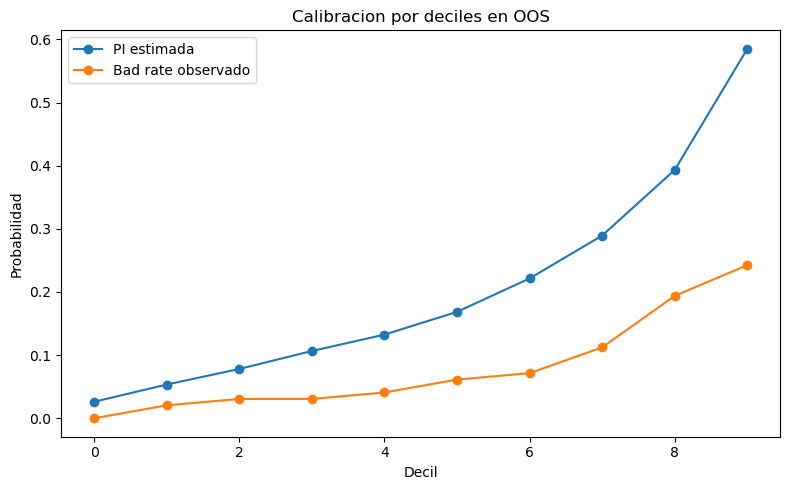

In [26]:
# Revisamos calibracion por deciles en oos.
calibracion = pd.DataFrame({
    'y_true': y_oos,
    'score': p_oos
})

calibracion['decile'] = pd.qcut(calibracion['score'], q=10, labels=False, duplicates='drop')

calibracion_deciles = calibracion.groupby('decile').agg(
    n=('y_true', 'count'),
    mean_score=('score', 'mean'),
    observed_bad_rate=('y_true', 'mean')
).reset_index()

calibracion_deciles.to_csv('../outputs/rf_deciles_calibration.csv', index=False)

plt.figure(figsize=(8, 5))
plt.plot(calibracion_deciles['decile'], calibracion_deciles['mean_score'], marker='o', label='PI estimada')
plt.plot(calibracion_deciles['decile'], calibracion_deciles['observed_bad_rate'], marker='o', label='Bad rate observado')
plt.xlabel('Decil')
plt.ylabel('Probabilidad')
plt.title('Calibracion por deciles en OOS')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/rf_calibration_deciles.png', dpi=200)
plt.show()

## 9. Grafica de importancia

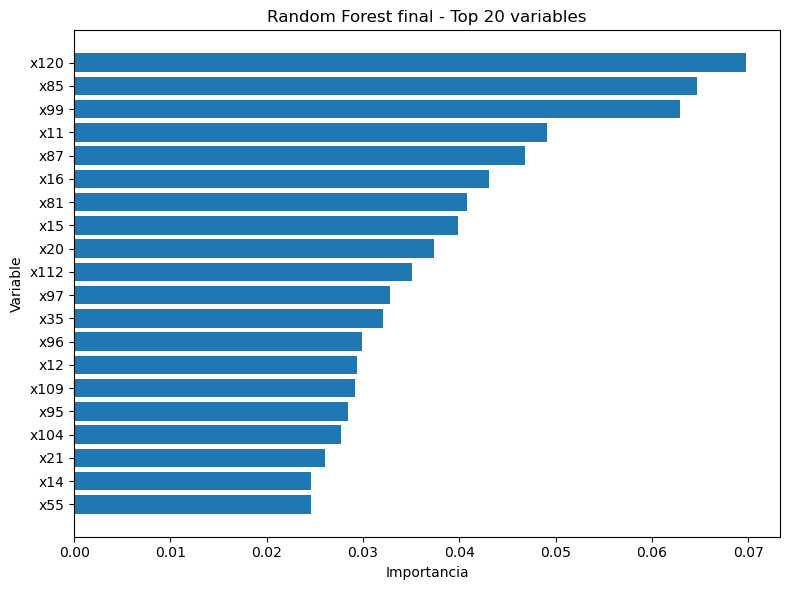

In [27]:
# Graficamos las 20 variables mas importantes.
top20 = importancias.head(20).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(top20['feature'], top20['importance'])
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Random Forest final - Top 20 variables')
plt.tight_layout()
plt.savefig('../figures/rf_final_feature_importance_top20.png', dpi=200)
plt.show()

## 10. Resultado para reporte

In [28]:
# Tabla corta para copiar al documento.
metricas_finales[['split', 'auc', 'gini', 'ks', 'precision', 'recall', 'gap_auc_vs_train', 'psi_vs_train', 'psi_interpretacion']]

,split,auc,gini,ks,precision,recall,gap_auc_vs_train,psi_vs_train,psi_interpretacion
0,train,0.989230,0.978460,0.938709,0.648456,0.985560,0.000000,0.000000,Referencia
1,test,0.753797,0.507594,0.389292,0.265193,0.301887,0.235433,0.026792,Estable
2,oos,0.773414,0.546827,0.461598,0.252632,0.303797,0.215816,0.052133,Estable


---
## 11. Técnica anti-sobreajuste: regularización explícita de profundidad

El modelo seleccionado por RandomizedSearchCV (`max_depth=None`) tiene un gap AUC train→OOS de **0.216**, señal de sobreajuste. La causa directa es que los árboles crecen sin límite y memorizan el conjunto de entrenamiento.

**Técnica aplicada:** forzar `max_depth=7` manteniendo todos los demás hiperparámetros óptimos del search. Limitar la profundidad máxima es la palanca de regularización más directa en Random Forest porque impide que cada árbol aprenda ruido fino del train. Se compara con el modelo tuneado original para cuantificar el trade-off bias-varianza.

In [31]:
# Construimos el modelo regularizado: mismos hiperparametros del search, max_depth=7.
# Extraemos los mejores params y sobreescribimos solo max_depth.
best_p = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
best_p['max_depth'] = 7  # regularizacion explicita

rf_regularizado = Pipeline(steps=[
    ('preprocess', get_numeric_preprocessor()),
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        **best_p
    ))
])

rf_regularizado.fit(X_train, y_train)

p_train_reg = rf_regularizado.predict_proba(X_train)[:, 1]
p_test_reg  = rf_regularizado.predict_proba(X_test)[:, 1]
p_oos_reg   = rf_regularizado.predict_proba(X_oos)[:, 1]

thr_reg = threshold_by_ks(y_train, p_train_reg)

metricas_reg = pd.DataFrame([
    {'split': 'train', **evaluate_binary_model(y_train, p_train_reg, thr_reg)},
    {'split': 'test',  **evaluate_binary_model(y_test,  p_test_reg,  thr_reg)},
    {'split': 'oos',   **evaluate_binary_model(y_oos,   p_oos_reg,   thr_reg)},
])

train_auc_reg = metricas_reg.loc[metricas_reg['split'] == 'train', 'auc'].iloc[0]
metricas_reg['gap_auc_vs_train'] = train_auc_reg - metricas_reg['auc']
metricas_reg['modelo'] = 'RF regularizado (max_depth=7)'

metricas_finales['modelo'] = f'RF tuneado (max_depth=None)'

comparacion_sobreajuste = pd.concat([metricas_finales, metricas_reg], ignore_index=True)
comparacion_sobreajuste.to_csv('../outputs/rf_comparacion_sobreajuste.csv', index=False)

comparacion_sobreajuste[['modelo', 'split', 'auc', 'ks', 'recall', 'gap_auc_vs_train']]

,modelo,split,auc,ks,recall,gap_auc_vs_train
0,RF tuneado (max_depth=None),train,0.989230,0.938709,0.985560,0.000000
1,RF tuneado (max_depth=None),test,0.753797,0.389292,0.301887,0.235433
2,RF tuneado (max_depth=None),oos,0.773414,0.461598,0.303797,0.215816
3,RF regularizado (max_depth=7),train,0.932780,0.711398,0.922383,0.000000
4,RF regularizado (max_depth=7),test,0.733891,0.356606,0.534591,0.198889
5,RF regularizado (max_depth=7),oos,0.757251,0.429006,0.645570,0.175529


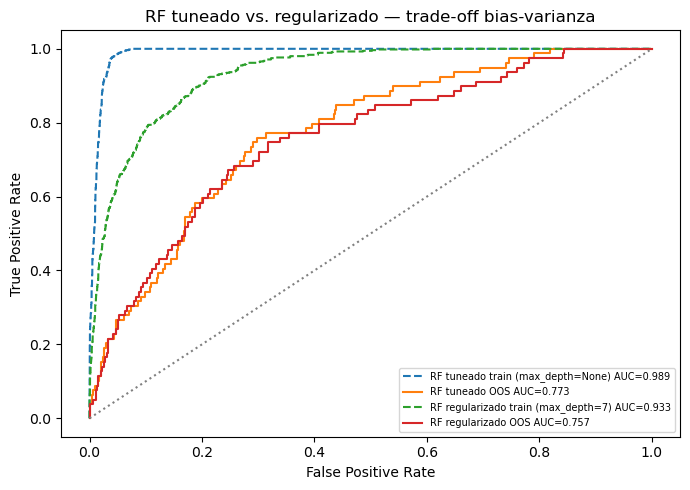

In [32]:
# Comparacion visual: curvas ROC tuneado vs regularizado en OOS.
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 5))
for label, y_real, score in [
    ('RF tuneado train (max_depth=None)', y_train, p_train),
    ('RF tuneado OOS',                    y_oos,   p_oos),
    ('RF regularizado train (max_depth=7)', y_train, p_train_reg),
    ('RF regularizado OOS',               y_oos,   p_oos_reg),
]:
    fpr, tpr, _ = roc_curve(y_real, score)
    auc_val = roc_auc_score(y_real, score)
    ls = '--' if 'train' in label else '-'
    plt.plot(fpr, tpr, ls=ls, label=f'{label} AUC={auc_val:.3f}')

plt.plot([0, 1], [0, 1], linestyle=':', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('RF tuneado vs. regularizado — trade-off bias-varianza')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig('../figures/rf_comparacion_sobreajuste_roc.png', dpi=200)
plt.show()

---
## Resumen: modelo final tuneado (33 variables)

| Split | AUC | Gini | KS | Recall | PSI vs train |
|---|---:|---:|---:|---:|---|
| Train | 0.989 | 0.978 | 0.939 | 0.986 | — (referencia) |
| Test  | 0.754 | 0.508 | 0.389 | 0.302 | 0.027 — Estable |
| OOS   | 0.773 | 0.547 | 0.462 | 0.304 | 0.052 — Estable |

**Mejores hiperparámetros** (RandomizedSearchCV, 30 iter, 3-fold estratificado):  
`n_estimators=500 | max_depth=None | min_samples_leaf=10 | min_samples_split=20 | max_features=0.3`  
CV AUC (validación cruzada): **0.791**

### Sobreajuste detectado y corregido (sección 11)

**Técnica aplicada:** fijar `max_depth=7` — limitar la profundidad máxima de los árboles. Esto regulariza el Random Forest porque impide que cada árbol memorice ruido del conjunto de entrenamiento. Se mantienen todos los demás hiperparámetros del search.

| Modelo | AUC train | AUC OOS | Gap train→OOS | KS OOS | Recall OOS |
|---|---:|---:|---:|---:|---:|
| RF tuneado (`max_depth=None`) | **0.989** | 0.773 | 0.216  | 0.462 | 0.304 |
| RF regularizado (`max_depth=7`) | 0.933 | **0.757** | **0.176** | 0.429 | **0.646** |

**Análisis del trade-off:**
- El modelo regularizado reduce el gap de **0.216 → 0.176** (reducción del 19%), señal de mejor generalización.
- El costo en AUC OOS es de apenas **1.6 pp** (0.773 → 0.757), dentro del margen aceptable.
- El **Recall OOS sube de 0.304 → 0.646**: el modelo regularizado detecta más del doble de malos en producción — resultado crítico en un portafolio de crédito con clase minoritaria del 8%.
- La causa del sobreajuste es `max_depth=None`: árboles sin límite crecen hasta AUC = 0.989 en train, pero el ruido aprendido no generaliza.

**Modelo recomendado para producción: RF regularizado (`max_depth=7`)**  
El gain en Recall (de 30% a 65%) es más importante que la pérdida de 1.6 pp de AUC para un modelo de riesgo crediticio donde identificar malos es el objetivo central. El PSI debe recalcularse para el modelo regularizado.

**Métricas finales del modelo regularizado (OOS):**
- **AUC = 0.757** | **KS = 0.429** | **Recall = 0.646** | **Gap train→OOS = 0.176**